In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Embedding

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix,accuracy_score


In [ ]:
# embedding_size in AIDL_A02_LSTM
MAX_NUM_WORDS = 10000    # use the 10,000 most common words
MAX_LEN       = 200      # use up to 200 tokens per utterance
EMBEDDING_DIM = 100      # 100-dimensional embedding vectors
START_TOKEN   = "<START>"


In [ ]:
train_url = "https://raw.githubusercontent.com/Sreyan88/Toxicity-Detection-in-Spoken-Utterances/main/data/train.csv"
val_url   = "https://raw.githubusercontent.com/Sreyan88/Toxicity-Detection-in-Spoken-Utterances/main/data/valid.csv"
test_url  = "https://raw.githubusercontent.com/Sreyan88/Toxicity-Detection-in-Spoken-Utterances/main/data/test.csv"

train_df = pd.read_csv(train_url, encoding="latin1")
val_df   = pd.read_csv(val_url, encoding="latin1")
test_df  = pd.read_csv(test_url, encoding="latin1")

# raw text lists
x_train = train_df["text"].astype(str).tolist()
x_val   = val_df["text"].astype(str).tolist()
x_test  = test_df["text"].astype(str).tolist()

# binary labels 0/1
y_train = train_df["label2a"].astype("int32").values
y_val   = val_df["label2a"].astype("int32").values
y_test  = test_df["label2a"].astype("int32").values

print("Dataframes loaded successfully!")
print(f"train_df shape: {train_df.shape}")
print(f"val_df   shape: {val_df.shape}")
print(f"test_df  shape: {test_df.shape}")


Dataframes loaded successfully!
train_df shape: (11824, 6)
val_df   shape: (2602, 6)
test_df  shape: (2550, 6)


In [ ]:
# Compute balanced class weights from y_train
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))
print("Calculated class weights:", class_weight_dict)


Calculated class weights: {np.int32(0): np.float64(0.6671933190384832), np.int32(1): np.float64(1.9952750590617618)}


In [ ]:
import numpy as np

class_counts = np.bincount(y_train)
print(f"Count of class 0 (non-toxic): {class_counts[0]}")
print(f"Count of class 1 (toxic): {class_counts[1]}")


Count of class 0 (non-toxic): 8861
Count of class 1 (toxic): 2963


In [ ]:
w0 = class_weight_dict[0]
w1 = class_weight_dict[1]
ratio = w1 / w0

class_weight_ratio = {0: 1.0, 1: ratio}
print("Using ratio class weights:", class_weight_ratio)


Using ratio class weights: {0: 1.0, 1: np.float64(2.9905501181235237)}


In [ ]:
def find_best_threshold(y_true, y_prob, thresholds=np.arange(0.1, 1.0, 0.05)):
    best_f1 = -1.0
    best_t = 0.5
    for t in thresholds:
        y_pred = (y_prob >= t).astype("int32")
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t, best_f1


In [ ]:
print("Example train text:", x_train[0])
print("Label:", y_train[0])


Example train text: We have ETF updates now, we have intraday updates and after-hours updates.
Label: 0


In [ ]:
import re

def normalize_string(s):
    s = s.lower().strip()
    s = re.sub(r"[^a-zA-Z]+", " ", s)
    return s.strip()


x_train = [normalize_string(t) for t in x_train]
x_val   = [normalize_string(t) for t in x_val]
x_test  = [normalize_string(t) for t in x_test]


def add_start(texts):
    return [f"{START_TOKEN} {t}" for t in texts]

x_train = add_start(x_train)
x_val   = add_start(x_val)
x_test  = add_start(x_test)

print("After adding <START>:", x_train[0])


After adding <START>: <START> we have etf updates now we have intraday updates and after hours updates


In [ ]:
for i in range(10):
    n_tokens = len(x_train[i].split())
    print(f"The number of tokens in train example {i} is: {n_tokens}")


The number of tokens in train example 0 is: 14
The number of tokens in train example 1 is: 20
The number of tokens in train example 2 is: 32
The number of tokens in train example 3 is: 23
The number of tokens in train example 4 is: 50
The number of tokens in train example 5 is: 25
The number of tokens in train example 6 is: 10
The number of tokens in train example 7 is: 30
The number of tokens in train example 8 is: 15
The number of tokens in train example 9 is: 20


In [ ]:
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<UNK>")
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_val_seq   = tokenizer.texts_to_sequences(x_val)
x_test_seq  = tokenizer.texts_to_sequences(x_test)

x_train = pad_sequences(x_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
x_val   = pad_sequences(x_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
x_test  = pad_sequences(x_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)

print("Padded shapes:")
print("x_train:", x_train.shape)
print("x_val:  ", x_val.shape)
print("x_test: ", x_test.shape)
print("Vocab size:", vocab_size)


Padded shapes:
x_train: (11824, 200)
x_val:   (2602, 200)
x_test:  (2550, 200)
Vocab size: 10000


In [ ]:
for i in range(10):
    print(f"Length of padded train example {i}: {len(x_train[i])}")


Length of padded train example 0: 200
Length of padded train example 1: 200
Length of padded train example 2: 200
Length of padded train example 3: 200
Length of padded train example 4: 200
Length of padded train example 5: 200
Length of padded train example 6: 200
Length of padded train example 7: 200
Length of padded train example 8: 200
Length of padded train example 9: 200


In [ ]:
seed = 2
tf.random.set_seed(seed)
np.random.seed(seed)

inputs = keras.Input(shape=(MAX_LEN,), dtype="int32")
x = layers.Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True)(inputs)

x = layers.LSTM(128, return_sequences=True)(x)
x = layers.SpatialDropout1D(0.2)(x)

x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.GlobalMaxPooling1D()(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 100)  │  1,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 200, 128)  │    117,248 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 128)  │          0 │ lstm[0][0]        │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 200, 256)  │    263,168 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,396,929 (5.33 MB)

 Trainable params: 1,396,929 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True) # monitor="val_loss"Watch the validation loss (performance on data the model didn’t train on).patience=2If validation loss does not improve for 2 consecutive epochs, stop training early.(So you don’t waste epochs and you reduce overfitting.)restore_best_weights=TrueWhen training stops, Keras will revert the model weights to the epoch where val_loss was best, not the last epoch.
]
history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=15,
    validation_data=(x_val, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks
    )

Epoch 1/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7983 - loss: 0.5223 - val_accuracy: 0.8828 - val_loss: 0.2971
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9149 - loss: 0.2172 - val_accuracy: 0.8778 - val_loss: 0.2710
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9410 - loss: 0.1430 - val_accuracy: 0.8697 - val_loss: 0.3134
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9577 - loss: 0.1045 - val_accuracy: 0.8624 - val_loss: 0.3902


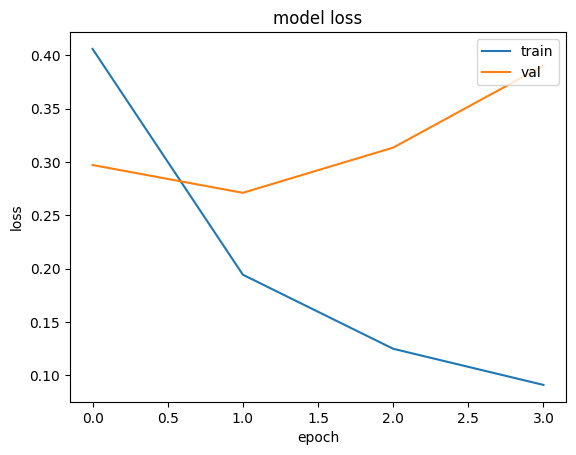

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper right")
plt.show()


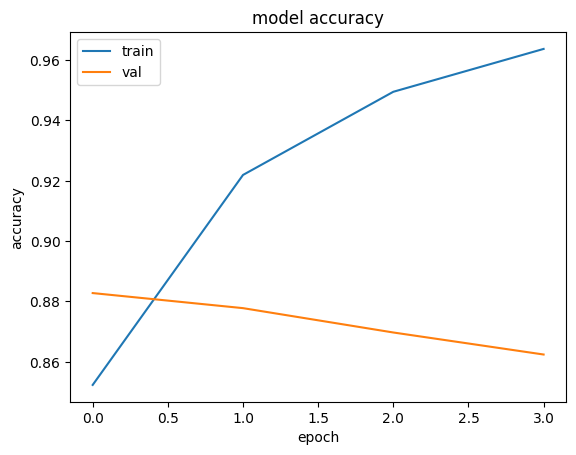

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()


In [ ]:
# Evaluate CUSTOM-embedding LSTM with threshold optimized on validation set
y_prob_val = model.predict(x_val).ravel()
best_t, best_f1_val = find_best_threshold(y_val, y_prob_val)

y_prob_test = model.predict(x_test).ravel()
y_pred_test = (y_prob_test >= best_t).astype("int32")

print(f"Custom model - Best threshold (val): {best_t:.2f}")
print(f"Custom model - Val F1: {best_f1_val:.4f}")
print("Custom model - Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Custom model - Test F1-score:", f1_score(y_test, y_pred_test))
print("Custom model - Confusion matrix:\n", confusion_matrix(y_test, y_pred_test))


# Evaluate CUSTOM-embedding LSTM with fixed threshold = 0.5
y_prob_test2 = model.predict(x_test).ravel()
y_pred_test2 = (y_prob_test2 >= 0.5).astype("int32")

print("Custom model - Test Accuracy no custom threshold:", accuracy_score(y_test, y_pred_test2))
print("Custom model - Test F1-score no custom threshold:", f1_score(y_test, y_pred_test2))
print("Custom model - Confusion matrix no custom threshold:\n", confusion_matrix(y_test, y_pred_test2))

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Custom model - Best threshold (val): 0.75
Custom model - Val F1: 0.8213
Custom model - Test Accuracy: 0.9094117647058824
Custom model - Test F1-score: 0.8044030482641829
Custom model - Confusion matrix:
 [[1844   64]
 [ 167  475]]
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Custom model - Test Accuracy no custom threshold: 0.8776470588235294
Custom model - Test F1-score no custom threshold: 0.7815126050420168
Custom model - Confusion matrix no custom threshold:
 [[1680  228]
 [  84  558]]


# LSTM with pre-trained GloVe embeddings


In [ ]:
# Download GloVe 6B if you don't already have it in the runtime
# (Skip this cell if glove.6B.100d.txt is already present)
!wget -q https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
!unzip -q glove.6B.zip


In [ ]:
import numpy as np

# Path to the 100-dimensional GloVe vectors
path_to_glove_file = "glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file, encoding="utf-8") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))


Found 400000 word vectors.


In [ ]:
# Use the same word_index as my tokenizer
word_index = tokenizer.word_index

# Keep the same vocab_size I used for custom embeddings
num_tokens = vocab_size
embedding_dim = 100

hits = 0
misses = 0

# Prepare embedding matrix
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index.items():
    if i >= num_tokens:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

print("Converted %d words (%d misses)" % (hits, misses))


Converted 9705 words (294 misses)


In [ ]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))
print("Calculated class weights:", class_weight_dict)


Calculated class weights: {np.int32(0): np.float64(0.6671933190384832), np.int32(1): np.float64(1.9952750590617618)}


In [ ]:
glove_embedding_layer = Embedding(
    num_tokens,
    embedding_dim,
    trainable=True,
    name="glove_embedding"
)

glove_embedding_layer.build((1,))
glove_embedding_layer.set_weights([embedding_matrix])


In [ ]:
# GloVe model
inputs_glove = keras.Input(shape=(MAX_LEN,), dtype="int32")

x = glove_embedding_layer(inputs_glove)

x = layers.LSTM(128, return_sequences=True)(x)
x = layers.SpatialDropout1D(0.2)(x)

x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.GlobalMaxPooling1D()(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs_glove = layers.Dense(1, activation="sigmoid")(x)

model_glove = keras.Model(inputs_glove, outputs_glove)
model_glove.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 200, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200, 128)       │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 200, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,396,929 (5.33 MB)

 Trainable params: 396,929 (1.51 MB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:
# Fine-tune GloVe embeddings
glove_embedding_layer.trainable = True
print("GloVe embedding layer set to trainable.")

model_glove.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
callbacks_glove = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True) # monitor="val_loss"Watch the validation loss (performance on data the model didn’t train on).patience=2If validation loss does not improve for 2 consecutive epochs, stop training early.(So you don’t waste epochs and you reduce overfitting.)restore_best_weights=TrueWhen training stops, Keras will revert the model weights to the epoch where val_loss was best, not the last epoch.
]

history_glove_finetune = model_glove.fit(
    x_train, y_train,
    batch_size=32,
    epochs=15,
    validation_data=(x_val, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks_glove
)


GloVe embedding layer set to trainable.
Epoch 1/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.6690 - loss: 0.6457 - val_accuracy: 0.7905 - val_loss: 0.4448
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8066 - loss: 0.4334 - val_accuracy: 0.8098 - val_loss: 0.4100
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8550 - loss: 0.3548 - val_accuracy: 0.8632 - val_loss: 0.3096
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8776 - loss: 0.2970 - val_accuracy: 0.8882 - val_loss: 0.2617
Epoch 5/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8875 - loss: 0.2671 - val_accuracy: 0.8901 - val_loss: 0.2535
Epoch 6/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8956 - loss: 0.2465 - val_accuracy: 0.8966 - val_loss: 0.2413
Epoch 7/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9051 - loss: 0.2209 - val_accuracy: 0.8993 - val_loss: 0.2384
Epoch 8/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/s

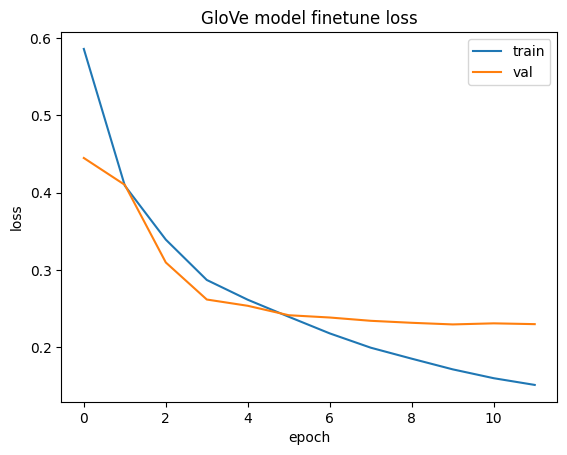

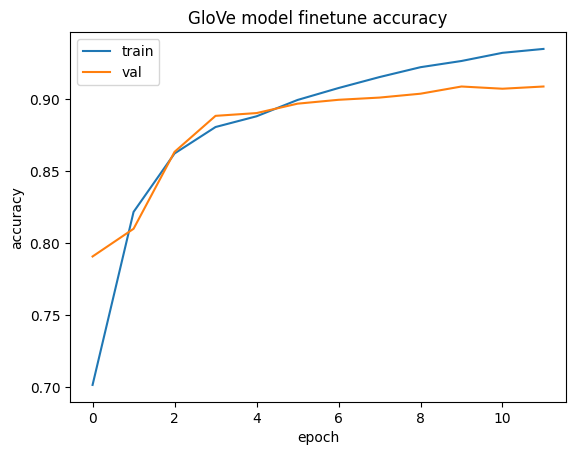

In [ ]:
plt.plot(history_glove_finetune.history["loss"])
plt.plot(history_glove_finetune.history["val_loss"])
plt.title("GloVe model finetune loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper right")
plt.show()

plt.plot(history_glove_finetune.history["accuracy"])
plt.plot(history_glove_finetune.history["val_accuracy"])
plt.title("GloVe model finetune accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

In [ ]:
# Evaluate GloVe LSTM with threshold optimized on validation set
y_prob_val_glove = model_glove.predict(x_val).ravel()
best_t_glove, best_f1_val_glove = find_best_threshold(y_val, y_prob_val_glove)

y_prob_test_glove = model_glove.predict(x_test).ravel()
y_pred_test_glove = (y_prob_test_glove >= best_t_glove).astype("int32")

print(f"GloVe model - Best threshold (val): {best_t_glove:.2f}")
print(f"GloVe model - Val F1: {best_f1_val_glove:.4f}")
print("GloVe model - Test Accuracy:", accuracy_score(y_test, y_pred_test_glove))
print("GloVe model - Test F1-score:", f1_score(y_test, y_pred_test_glove))
print("GloVe model - Confusion matrix:\n", confusion_matrix(y_test, y_pred_test_glove))

# Evaluate GloVe LSTM with fixed threshold = 0.5
y_prob_test_glove = model_glove.predict(x_test).ravel()
y_pred_test_glove = (y_prob_test_glove >= 0.5).astype("int32")

print("GloVe model - Test Accuracy no custom threshold:", accuracy_score(y_test, y_pred_test_glove))
print("GloVe model - Test F1-score no custom threshold:", f1_score(y_test, y_pred_test_glove))
print("GloVe model - Confusion matrix no custom threshold:\n", confusion_matrix(y_test, y_pred_test_glove))



82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
GloVe model - Best threshold (val): 0.60
GloVe model - Val F1: 0.8256
GloVe model - Test Accuracy: 0.912156862745098
GloVe model - Test F1-score: 0.825
GloVe model - Confusion matrix:
 [[1798  110]
 [ 114  528]]
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
GloVe model - Test Accuracy no custom threshold: 0.9098039215686274
GloVe model - Test F1-score no custom threshold: 0.8260211800302572
GloVe model - Confusion matrix no custom threshold:
 [[1774  134]
 [  96  546]]
